# LSTM Workshop Notebook: Single-Step vs Multi-Step Forecasting

This workshop notebook shows **two simple LSTM forecasting approaches** for water-resources time series:

1. **Single-step forecasting**: use the last 24 hours to predict the next hour  
2. **Multi-step forecasting**: use the last 24 hours to predict the next 24 hours

The goal is to keep the workflow **clear, teachable, and easy to modify**.

---

## What this notebook does
- loads an hourly CSV file
- selects numeric input features
- creates supervised learning sequences
- trains a simple LSTM model for each case
- evaluates performance
- plots predictions against observations

## Assumptions
- The CSV file is named `Merged-update_hourly.csv`
- The target variable is set in the `target_column` cell below
- The data are already hourly or close to hourly

You can adapt this notebook for:
- stage forecasting
- flow forecasting
- rainfall-runoff applications
- reservoir or canal operations

# Disclaimer: 
Portions of this code were developed with assistance from ChatGPT and were subsequently reviewed, edited, 
and organized for instructional use. The code is provided as a teaching example only and has not been fully
validated for professional engineering, regulatory, design, or safety-critical applications. Users are responsible 
for independently checking assumptions, data quality, parameter choices, numerical results, and suitability 
for any specific water resources application.

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Make plots a bit larger for workshop use
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11


## 1. Load the hourly dataset

In [4]:
file_path = "Merged-update_hourly.csv"

df = pd.read_csv(file_path)
print("Data shape:", df.shape)
df.head()


Data shape: (96432, 20)


,Time,WS_S1,WS_S4,FLOW_S25A,GATE_S25A,HWS_S25A,TWS_S25A,FLOW_S25B,GATE_S25B,GATE_S25B2,HWS_S25B,TWS_S25B,PUMP_S25B,FLOW_S26,GATE_S26_1,GATE_S26_2,HWS_S26,TWS_S26,PUMP_S26,MEAN_RAIN
0,1/1/10 00:00,0.33,0.34,0.0,0.0,2.17,0.49,0.0,0.0,0.0,2.84,0.58,0.0,0.0,0.0,0.0,2.78,0.505,0.0,0.0
1,1/1/10 01:00,-0.29,-0.28,0.0,0.0,2.17,0.02,0.0,0.0,0.0,2.84,-0.07,0.0,0.0,0.0,0.0,2.78,-0.110,0.0,0.0
2,1/1/10 02:00,-0.81,-0.73,0.0,0.0,2.17,-0.49,0.0,0.0,0.0,2.84,-0.62,0.0,0.0,0.0,0.0,2.79,-0.650,0.0,0.0
3,1/1/10 03:00,-0.98,-0.85,0.0,0.0,2.15,-0.75,0.0,0.0,0.0,2.83,-0.82,0.0,0.0,0.0,0.0,2.79,-0.850,0.0,0.0
4,1/1/10 04:00,-0.69,-0.49,0.0,0.0,2.13,-0.55,0.0,0.0,0.0,2.84,-0.53,0.0,0.0,0.0,0.0,2.79,-0.550,0.0,0.0


## 2. Basic cleaning and setup

This section:
- tries to identify a datetime column
- keeps only numeric columns for modeling
- lets you choose the target variable to forecast


In [6]:
# Try to detect a datetime column automatically
possible_time_cols = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()]

if possible_time_cols:
    time_col = possible_time_cols[0]
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.sort_values(time_col).reset_index(drop=True)
    print("Using time column:", time_col)
else:
    time_col = None
    print("No datetime column detected automatically.")

# Keep numeric columns only for the model
numeric_df = df.select_dtypes(include=[np.number]).copy()
print("Numeric columns:")
print(list(numeric_df.columns))
print("\nNumeric data shape:", numeric_df.shape)


C:\Users\jobeysek\AppData\Local\Temp\ipykernel_14584\3404525346.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col], errors="coerce")


Using time column: Time
Numeric columns:
['WS_S1', 'WS_S4', 'FLOW_S25A', 'GATE_S25A', 'HWS_S25A', 'TWS_S25A', 'FLOW_S25B', 'GATE_S25B', 'GATE_S25B2', 'HWS_S25B', 'TWS_S25B', 'PUMP_S25B', 'FLOW_S26', 'GATE_S26_1', 'GATE_S26_2', 'HWS_S26', 'TWS_S26', 'PUMP_S26', 'MEAN_RAIN']

Numeric data shape: (96432, 19)


In [7]:
# Choose the target column you want to forecast
# Change this to the variable most relevant for your workshop
target_column = numeric_df.columns[0]

print("Selected target column:", target_column)


Selected target column: WS_S1


In [8]:
# Handle missing values simply for training purposes
# For a workshop, this is easier to explain than advanced gap filling.
numeric_df = numeric_df.interpolate(limit_direction="both")
numeric_df = numeric_df.dropna().reset_index(drop=True)

print("Cleaned numeric data shape:", numeric_df.shape)
numeric_df.head()


Cleaned numeric data shape: (96432, 19)


,WS_S1,WS_S4,FLOW_S25A,GATE_S25A,HWS_S25A,TWS_S25A,FLOW_S25B,GATE_S25B,GATE_S25B2,HWS_S25B,TWS_S25B,PUMP_S25B,FLOW_S26,GATE_S26_1,GATE_S26_2,HWS_S26,TWS_S26,PUMP_S26,MEAN_RAIN
0,0.33,0.34,0.0,0.0,2.17,0.49,0.0,0.0,0.0,2.84,0.58,0.0,0.0,0.0,0.0,2.78,0.505,0.0,0.0
1,-0.29,-0.28,0.0,0.0,2.17,0.02,0.0,0.0,0.0,2.84,-0.07,0.0,0.0,0.0,0.0,2.78,-0.110,0.0,0.0
2,-0.81,-0.73,0.0,0.0,2.17,-0.49,0.0,0.0,0.0,2.84,-0.62,0.0,0.0,0.0,0.0,2.79,-0.650,0.0,0.0
3,-0.98,-0.85,0.0,0.0,2.15,-0.75,0.0,0.0,0.0,2.83,-0.82,0.0,0.0,0.0,0.0,2.79,-0.850,0.0,0.0
4,-0.69,-0.49,0.0,0.0,2.13,-0.55,0.0,0.0,0.0,2.84,-0.53,0.0,0.0,0.0,0.0,2.79,-0.550,0.0,0.0


## 3. Split data into training and testing sets

We use the first 80% for training and the last 20% for testing to preserve time order.


In [10]:
train_size = int(len(numeric_df) * 0.8)

train_df = numeric_df.iloc[:train_size].copy()
test_df  = numeric_df.iloc[train_size:].copy()

print("Training rows:", len(train_df))
print("Testing rows :", len(test_df))


Training rows: 77145
Testing rows : 19287


## 4. Scale inputs and target separately

We scale:
- all predictors with one scaler
- the target variable with another scaler

This makes inverse transformation of predictions much easier.


In [12]:
feature_columns = list(numeric_df.columns)

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_X_scaled = x_scaler.fit_transform(train_df[feature_columns])
test_X_scaled  = x_scaler.transform(test_df[feature_columns])

train_y_scaled = y_scaler.fit_transform(train_df[[target_column]])
test_y_scaled  = y_scaler.transform(test_df[[target_column]])

print("Scaled input shape (train):", train_X_scaled.shape)
print("Scaled target shape (train):", train_y_scaled.shape)


Scaled input shape (train): (77145, 19)
Scaled target shape (train): (77145, 1)


## 5. Helper function to create sequences

This function converts time series data into LSTM-ready samples:

- `lookback = 24` means use the previous 24 hours as input
- `horizon = 1` means predict 1 hour ahead
- `horizon = 24` means predict the next 24 hours


In [14]:
def create_sequences(X, y, lookback=24, horizon=1):
    """
    Create LSTM-ready input/output sequences.

    Parameters
    ----------
    X : array
        Scaled predictor matrix with shape (n_samples, n_features)
    y : array
        Scaled target array with shape (n_samples, 1)
    lookback : int
        Number of past time steps used as input
    horizon : int
        Number of future time steps to predict

    Returns
    -------
    X_seq : array of shape (n_sequences, lookback, n_features)
    y_seq : array of shape (n_sequences, horizon)
    """
    X_seq, y_seq = [], []

    for i in range(lookback, len(X) - horizon + 1):
        X_seq.append(X[i - lookback:i, :])
        y_seq.append(y[i:i + horizon, 0])

    return np.array(X_seq), np.array(y_seq)


## 6. Build a simple LSTM model

This is intentionally small and easy to explain:

**Past conditions → LSTM memory layer → forecast**


In [16]:
def build_lstm_model(input_shape, horizon):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(horizon)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )
    return model


## 7. Experiment A: Single-step forecasting

Use the previous 24 hours to predict the **next 1 hour**.


In [18]:
lookback = 24
single_horizon = 1

X_train_1, y_train_1 = create_sequences(train_X_scaled, train_y_scaled, lookback=lookback, horizon=single_horizon)
X_test_1,  y_test_1  = create_sequences(test_X_scaled,  test_y_scaled,  lookback=lookback, horizon=single_horizon)

print("Single-step X_train shape:", X_train_1.shape)
print("Single-step y_train shape:", y_train_1.shape)


Single-step X_train shape: (77121, 24, 19)
Single-step y_train shape: (77121, 1)


In [19]:
single_model = build_lstm_model(
    input_shape=(X_train_1.shape[1], X_train_1.shape[2]),
    horizon=single_horizon
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_single = single_model.fit(
    X_train_1, y_train_1,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1,
    shuffle=False,
    callbacks=[early_stop]
)


Epoch 1/30


C:\Users\jobeysek\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


964/964 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0024 - mae: 0.0318 - val_loss: 0.0066 - val_mae: 0.0476
Epoch 2/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 3.4251e-04 - mae: 0.0138 - val_loss: 5.0661e-04 - val_mae: 0.0183
Epoch 3/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 2.2829e-04 - mae: 0.0117 - val_loss: 4.3322e-04 - val_mae: 0.0169
Epoch 4/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 1.8046e-04 - mae: 0.0103 - val_loss: 5.9971e-04 - val_mae: 0.0199
Epoch 5/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 1.5964e-04 - mae: 0.0096 - val_loss: 8.0758e-04 - val_mae: 0.0214
Epoch 6/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 1.5056e-04 - mae: 0.0093 - val_loss: 3.4980e-04 - val_mae: 0.0152
Epoch 7/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 1.3756e-04 - mae: 0.0089 - val_loss: 3.3274e-04 - val_mae: 0.0147
Epoch 8/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 1.2932e-04 - mae: 0.0086 - val_loss: 3.3229e-04 - val_mae: 0.0146
Epoch 9

In [20]:
# Predict and convert back to original units
y_pred_1_scaled = single_model.predict(X_test_1, verbose=0)

y_pred_1 = y_scaler.inverse_transform(y_pred_1_scaled)
y_true_1 = y_scaler.inverse_transform(y_test_1.reshape(-1, 1))

rmse_1 = np.sqrt(mean_squared_error(y_true_1, y_pred_1))
mae_1 = mean_absolute_error(y_true_1, y_pred_1)

print(f"Single-step RMSE: {rmse_1:.4f}")
print(f"Single-step MAE : {mae_1:.4f}")


Single-step RMSE: 0.1329
Single-step MAE : 0.1141


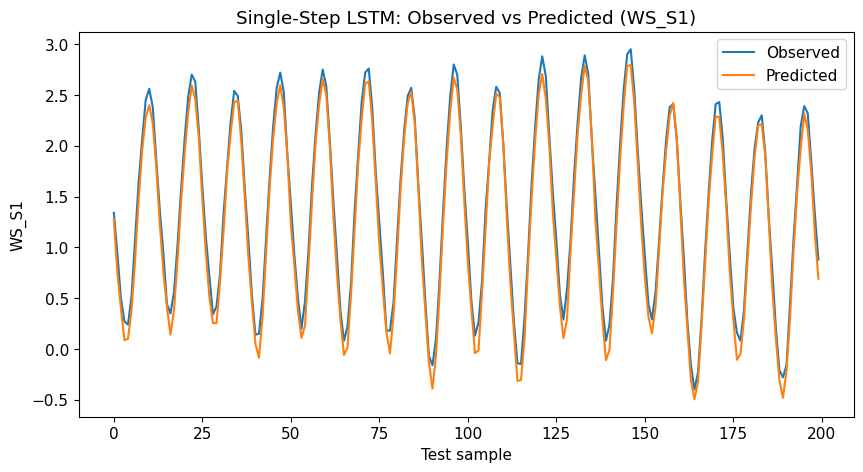

In [21]:
plt.figure()
plt.plot(y_true_1[:200], label="Observed")
plt.plot(y_pred_1[:200], label="Predicted")
plt.title(f"Single-Step LSTM: Observed vs Predicted ({target_column})")
plt.xlabel("Test sample")
plt.ylabel(target_column)
plt.legend()
plt.show()


## 8. Experiment B: Multi-step forecasting

Use the previous 24 hours to predict the **next 24 hours**.


In [23]:
multi_horizon = 24

X_train_24, y_train_24 = create_sequences(train_X_scaled, train_y_scaled, lookback=lookback, horizon=multi_horizon)
X_test_24,  y_test_24  = create_sequences(test_X_scaled,  test_y_scaled,  lookback=lookback, horizon=multi_horizon)

print("Multi-step X_train shape:", X_train_24.shape)
print("Multi-step y_train shape:", y_train_24.shape)


Multi-step X_train shape: (77098, 24, 19)
Multi-step y_train shape: (77098, 24)


In [24]:
multi_model = build_lstm_model(
    input_shape=(X_train_24.shape[1], X_train_24.shape[2]),
    horizon=multi_horizon
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_multi = multi_model.fit(
    X_train_24, y_train_24,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1,
    shuffle=False,
    callbacks=[early_stop]
)


C:\Users\jobeysek\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - loss: 0.0037 - mae: 0.0428 - val_loss: 0.0028 - val_mae: 0.0405
Epoch 2/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - loss: 0.0014 - mae: 0.0290 - val_loss: 0.0024 - val_mae: 0.0376
Epoch 3/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - loss: 0.0012 - mae: 0.0276 - val_loss: 0.0022 - val_mae: 0.0358
Epoch 4/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - loss: 0.0011 - mae: 0.0265 - val_loss: 0.0021 - val_mae: 0.0343
Epoch 5/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - loss: 9.6349e-04 - mae: 0.0243 - val_loss: 0.0017 - val_mae: 0.0306
Epoch 6/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - loss: 8.4068e-04 - mae: 0.0226 - val_loss: 0.0016 - val_mae: 0.0301
Epoch 7/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - loss: 7.9801e-04 - mae: 0.0220 - val_loss: 0.0016 - val_mae: 0.0298
Epoch 8/30
964/964 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - loss: 7.6953e-04 - mae: 0.0216 - val_loss: 0.0016 - val_mae: 0.0296
Epoch 9/30
964/964 ━━━━━

In [25]:
# Predict the full 24-hour horizon
y_pred_24_scaled = multi_model.predict(X_test_24, verbose=0)

# Inverse transform each row by flattening, then reshape back
y_pred_24 = y_scaler.inverse_transform(y_pred_24_scaled.reshape(-1, 1)).reshape(y_pred_24_scaled.shape)
y_true_24 = y_scaler.inverse_transform(y_test_24.reshape(-1, 1)).reshape(y_test_24.shape)

# Evaluate all forecasted values together
rmse_24 = np.sqrt(mean_squared_error(y_true_24.flatten(), y_pred_24.flatten()))
mae_24 = mean_absolute_error(y_true_24.flatten(), y_pred_24.flatten())

print(f"Multi-step RMSE (all horizons combined): {rmse_24:.4f}")
print(f"Multi-step MAE  (all horizons combined): {mae_24:.4f}")


Multi-step RMSE (all horizons combined): 0.2793
Multi-step MAE  (all horizons combined): 0.2225


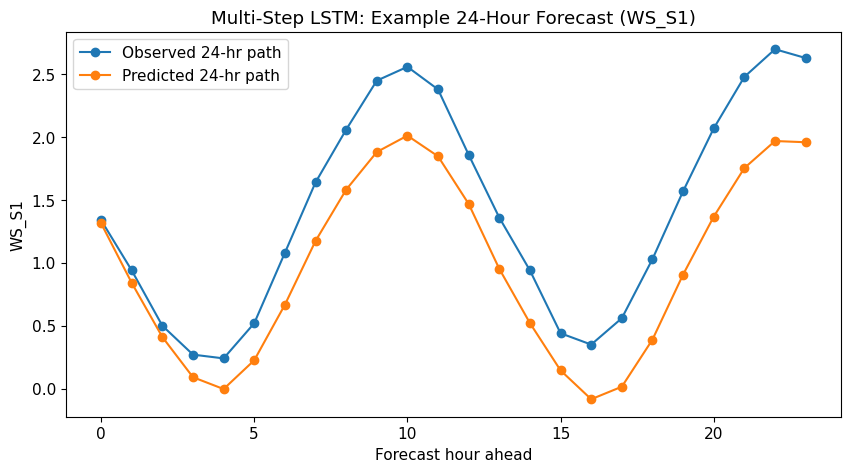

In [26]:
# Plot one example 24-hour forecast
example_index = 0

plt.figure()
plt.plot(y_true_24[example_index], marker="o", label="Observed 24-hr path")
plt.plot(y_pred_24[example_index], marker="o", label="Predicted 24-hr path")
plt.title(f"Multi-Step LSTM: Example 24-Hour Forecast ({target_column})")
plt.xlabel("Forecast hour ahead")
plt.ylabel(target_column)
plt.legend()
plt.show()


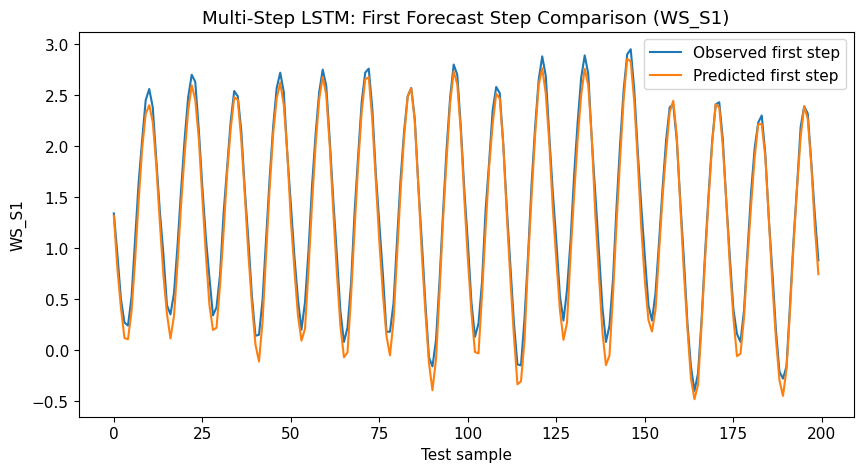

In [27]:
# Plot only the first forecast step from each 24-hour prediction window
plt.figure()
plt.plot(y_true_24[:, 0][:200], label="Observed first step")
plt.plot(y_pred_24[:, 0][:200], label="Predicted first step")
plt.title(f"Multi-Step LSTM: First Forecast Step Comparison ({target_column})")
plt.xlabel("Test sample")
plt.ylabel(target_column)
plt.legend()
plt.show()


## 9. Compare the two approaches

Single-step forecasting is usually:
- easier to explain
- easier to train
- often more accurate for the immediate next step

Multi-step forecasting is useful when you need:
- an entire forecast horizon
- operational planning for the next several hours
- a full trajectory instead of a single value


In [29]:
comparison = pd.DataFrame({
    "Model": ["Single-step (1 hour ahead)", "Multi-step (24 hours ahead)"],
    "RMSE": [rmse_1, rmse_24],
    "MAE": [mae_1, mae_24]
})

comparison


,Model,RMSE,MAE
0,Single-step (1 hour ahead),0.132949,0.114141
1,Multi-step (24 hours ahead),0.279339,0.222535


## 10. Teaching notes

### How to explain this to water resources engineers
- The **input window** is the recent hydrologic history
- The **LSTM layer** learns which past conditions matter
- The **output** can be one future value or many future values

### Good workshop discussion points
- Why might a 24-hour lookback be useful?
- When is single-step forecasting enough?
- When do operations require a full multi-hour forecast?
- How would results change if rainfall, tide, or pumping were added or removed?

### Easy ways to extend this notebook
- change `target_column`
- change `lookback`
- change the forecast horizon
- compare against Random Forest or XGBoost
